<center>
    <font size="5"> Zaawansowane Metody Uczenia Maszynowego i Głębokiegio<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Informatyka<br>Specjalność: Systemy inteligentne i rozszerzona rzeczywistość</small>
    </font>
</center>
<br>


## Temat projektu: Klasyfikacja ras psów. Porównanie modelu CNN EfficientNetV2L (transfer learning) z prostym CNN.
### Autorzy: Mateusz Wójtowicz SIiRRz2, Jakub Kieliński SIiRRz1
### Dataset wykorzystany do treningu: [Link Kaggle](https://www.kaggle.com/competitions/dog-breed-identification/overview)

## Opis datasetu - Dog Breed Identification

### Typ zadania:
- Computer Vision
- Klasyfikacja wieloklasowa
- Liczba klas: 120 (rasy psow)
- Kazdy obraz ma doklanie 1 etykiete

### Liczba probek:
- Zbior treningowy: 10 222 obrazy
- Zbior testowy: 10 357 obrazow
- Format obrazu: JPG

### Strutkura katalogu po rozpakowaniu

```text
dog-breed-identification/
├── train/
│   ├── <image_id>.jpg
│   └── ...
├── test/
│   ├── <image_id>.jpg
│   └── ...
├── labels.csv
└── sample_submission.csv
```

### Plik `labels.csv`
- Kolumny:
  - `id` – identyfikator obrazu (nazwa pliku bez rozszerzenia `.jpg`)
  - `breed` – etykieta klasy (nazwa rasy)
- Jedna etykieta na jeden obraz
- 120 unikalnych wartości w kolumnie `breed`

### Dane testowe
- Brak etykiet
- Struktura plików identyczna jak w `train/`
- Przeznaczone do ewaluacji modelu

Importowanie wymaganych bibliotek

In [39]:
import os, random
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lime

from lime import lime_image
from skimage.segmentation import mark_boundaries

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"Tensorflow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

Tensorflow Version: 2.17.0
NumPy Version: 1.26.4
Pandas Version: 2.2.3


Sprawdzanie dostepnosci GPU

In [2]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        gpu_name = details.get('device_name', 'Unknown GPU')
        print(f"Available GPU: {gpu_name}")
else:
    print("No GPU found.")

Available GPU: NVIDIA GeForce RTX 5070 Ti


I0000 00:00:1770579320.134177   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.507683   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.507780   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.508966   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Konfiguracja seed, path do datasetu, autotune + podstawowe parametry modelu

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
LABELS_CSV = os.path.join(DATA_DIR, "labels.csv")

BATCH_SIZE = 32
IMG_SIZE = 384
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 30

# performance management
AUTOTUNE = tf.data.AUTOTUNE

Wczytywanie etykiet + stratified split (zachowanie oryginalnych proporcji klas w obu podzbiorach)

In [4]:
df = pd.read_csv(LABELS_CSV)
df["filename"] = df["id"].astype(str) + ".jpg"
df["filepath"] = df["filename"].apply(lambda x: os.path.join(TRAIN_DIR, x))

# mapowanie klas
class_names = sorted(df["breed"].unique().tolist())
class_to_idx = {c:i for i,c in enumerate(class_names)}
num_classes = len(class_names)

df["label"] = df["breed"].map(class_to_idx).astype(int)

# podzial danych na treningowe i walidacyjne 80/20
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

print("Train len:", len(train_df), "Val len:", len(val_df), "Num Classes:", num_classes)

Train len: 8177 Val len: 2045 Num Classes: 120


Tworzenie datasetu treningowego i walidacyjnego z asynchronicznym wczytywaniem

In [5]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    return img, tf.one_hot(label, depth=num_classes)


def make_dataset(df, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label"].values))
    
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

I0000 00:00:1770579320.579661   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.579720   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.579737   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.747283   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770579320.747339   67546 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-08

Dodanie augmentacji

In [6]:
# augmentacje w modelu dzialajace tylko na treningu
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.15)
], name="augmentation")

Budwanie modelu EfficientNetV2L

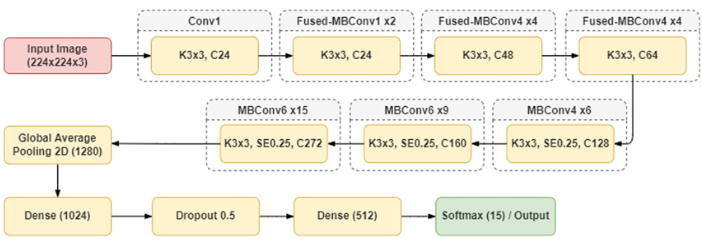

Zrodlo: https://www.researchgate.net/figure/EfficientNetV2L-classification-model-architecture_fig2_368326388

### Fused-MBConv
 W początkowych warstwach sieci zastosowano bloki Fused-MBConv, które łączą operacje splotu (convolution) i projekcji  pozwalajac na znacznie lepsze wykorzystanie akceleratorów sprzętowych (GPU/TPU).

### Progressive Learning
Model wykorzystuje technikę progresywnego uczenia, dynamicznie dostosowując rozmiar obrazu wejściowego oraz siłę regularyzacji (Dropout, Data Augmentation) w trakcie trwania epok.

Wersja Large jest największym wariantem rodziny, posiadającym ~118 milionów parametrów. 
Została wytrenowana na zbiorze ImageNet-21k, z kolei fine-tunning na ImageNet-1k.

In [7]:
def build_model():
    base = keras.applications.EfficientNetV2L(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # stage 1 training
    base.trainable = False
    
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)
    x = keras.layers.Lambda(preprocess_input)(x)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(
        512,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.35)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    return model, base


model, base_model = build_model()

loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
        keras.metrics.CategoricalAccuracy(name="top1"),
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5"),
    ]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 384, 384, 3)       0         
                                                                 
 lambda (Lambda)             (None, 384, 384, 3)       0         
                                                                 
 efficientnetv2-l (Function  (None, 12, 12, 1280)      117746848 
 al)                                                             
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0     

Definiowanie Callbackow modelu

In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

Trening modelu (Stage 1)

In [9]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/256 [..............................] - ETA: 1:43:02 - loss: 4.8537 - top1: 0.0000e+00 - top5: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1770579354.046895   67690 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579354.048202   67690 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579354.048634   67690 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579354.049253   67690 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579354.049764   67690 gpu_timer.cc:114] Skipping the delay kernel, measu

  2/256 [..............................] - ETA: 2:36 - loss: 4.8624 - top1: 0.0000e+00 - top5: 0.0625   

...

256/256 [==============================] - ETA: 0s - loss: 1.3899 - top1: 0.8326 - top5: 0.9309

W0000 00:00:1770579416.417108   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579416.419092   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.273086   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.273515   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.273948   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.274431   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.274912   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.275500   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579435.276488   67688 gp

256/256 [==============================] - 110s 337ms/step - loss: 1.3899 - top1: 0.8326 - top5: 0.9309 - val_loss: 0.7124 - val_top1: 0.9467 - val_top5: 0.9961 - lr: 0.0010
Epoch 2/10
256/256 [==============================] - ETA: 0s - loss: 0.7996 - top1: 0.9264 - top5: 0.9960

W0000 00:00:1770579502.715467   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.716352   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.716618   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.716903   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.717200   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.717565   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.718135   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.718878   67693 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770579502.719474   67693 gp

256/256 [==============================] - 77s 303ms/step - loss: 0.7996 - top1: 0.9264 - top5: 0.9960 - val_loss: 0.7197 - val_top1: 0.9457 - val_top5: 0.9961 - lr: 0.0010
Epoch 3/10
256/256 [==============================] - ETA: 0s - loss: 0.7845 - top1: 0.9272 - top5: 0.9976
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
256/256 [==============================] - 77s 300ms/step - loss: 0.7845 - top1: 0.9272 - top5: 0.9976 - val_loss: 0.7137 - val_top1: 0.9457 - val_top5: 0.9946 - lr: 0.0010
Epoch 4/10
256/256 [==============================] - 80s 312ms/step - loss: 0.7468 - top1: 0.9413 - top5: 0.9985 - val_loss: 0.7016 - val_top1: 0.9491 - val_top5: 0.9966 - lr: 5.0000e-04
Epoch 5/10
256/256 [==============================] - 80s 313ms/step - loss: 0.7395 - top1: 0.9393 - top5: 0.9991 - val_loss: 0.6973 - val_top1: 0.9501 - val_top5: 0.9956 - lr: 5.0000e-04
Epoch 6/10
256/256 [==============================] - 81s 316ms/step - loss: 0.7291 - top1: 0.9

Callbacki dla Stage 2

In [10]:
callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        "best_model_stage2.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

Stage 2 -> Fine-tunning (odmrazanie czesci backbone + niski LR)

In [11]:
# 1. Unfreeze the base model
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[:-50]: 
    layer.trainable = False

total_steps = len(train_ds) * EPOCHS_STAGE2
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-6,
    decay_steps=total_steps,
    alpha=0.1 
)

optimizer = keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=0.05)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.15)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
        keras.metrics.CategoricalAccuracy(name="top1"),
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5"),
    ]
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2
)

Epoch 1/30


2026-02-08 19:49:37.136843: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetv2-l/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring featu

  1/256 [..............................] - ETA: 1:38:07 - loss: 1.4159 - top1: 1.0000 - top5: 1.0000

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


256/256 [==============================] - 117s 369ms/step - loss: 1.4135 - top1: 0.9550 - top5: 1.0000 - val_loss: 1.3686 - val_top1: 0.9545 - val_top5: 0.9956
Epoch 2/30
256/256 [==============================] - 86s 336ms/step - loss: 1.4031 - top1: 0.9549 - top5: 0.9999 - val_loss: 1.3676 - val_top1: 0.9535 - val_top5: 0.9956
Epoch 3/30
256/256 [==============================] - 88s 344ms/step - loss: 1.4002 - top1: 0.9548 - top5: 0.9998 - val_loss: 1.3653 - val_top1: 0.9531 - val_top5: 0.9956
Epoch 4/30
256/256 [==============================] - 88s 345ms/step - loss: 1.4000 - top1: 0.9556 - top5: 0.9995 - val_loss: 1.3650 - val_top1: 0.9521 - val_top5: 0.9956
Epoch 5/30
256/256 [==============================] - 89s 350ms/step - loss: 1.3918 - top1: 0.9598 - top5: 0.9998 - val_loss: 1.3642 - val_top1: 0.9526 - val_top5: 0.9956
Epoch 6/30
256/256 [==============================] - 88s 345ms/step - loss: 1.3951 - top1: 0.9589 - top5: 0.9996 - val_loss: 1.3629 - val_top1: 0.9526 - v

Metryki dla modelu EfficientNetV2L Transfer learning

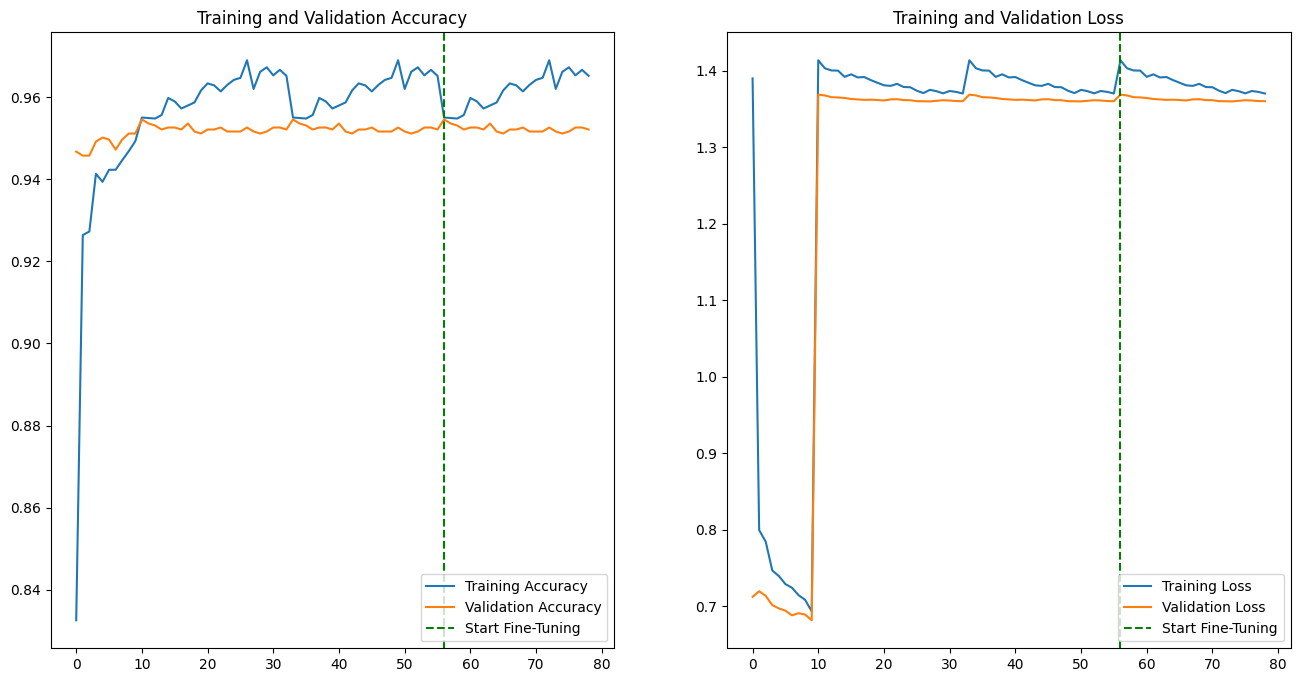

In [ ]:
def plot_history(history1, history2=None):
    acc = history1.history['top1'][:]
    val_acc = history1.history['val_top1'][:]
    loss = history1.history['loss'][:]
    val_loss = history1.history['val_loss'][:]
    
    start_fine_tuning = len(acc)
    
    if history2:
        acc += history2.history['top1']
        val_acc += history2.history['val_top1']
        loss += history2.history['loss']
        val_loss += history2.history['val_loss']
        
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 8))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    if history2:
        plt.axvline(x=start_fine_tuning, color='green', linestyle='--', label='Start Fine-Tuning')
        
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    if history2:
        plt.axvline(x=start_fine_tuning, color='green', linestyle='--', label='Start Fine-Tuning')
        
    plt.legend(loc='lower right')
    plt.title('Training and Validation Loss')
    plt.show()


plot_history(history_stage1, history_stage2)

Confussion Matrix + Classification Report

------------------------------

--- CLASSIFICATION REPORT (Top/Bottom Performers) ---

Top 5 Breeds (Best F1-Score):
                  precision  recall  f1-score
standard_poodle         1.0     1.0       1.0
sussex_spaniel          1.0     1.0       1.0
tibetan_mastiff         1.0     1.0       1.0
basset                  1.0     1.0       1.0
blenheim_spaniel        1.0     1.0       1.0

Bottom 5 Breeds (Worst F1-Score):
                    precision    recall  f1-score
border_collie        0.700000  1.000000  0.823529
australian_terrier   0.888889  0.761905  0.820513
miniature_poodle     0.857143  0.750000  0.800000
collie               0.909091  0.588235  0.714286
eskimo_dog           0.800000  0.307692  0.444444

--- CONFUSION MATRIX ---


2026-02-08 22:21:56.677358: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


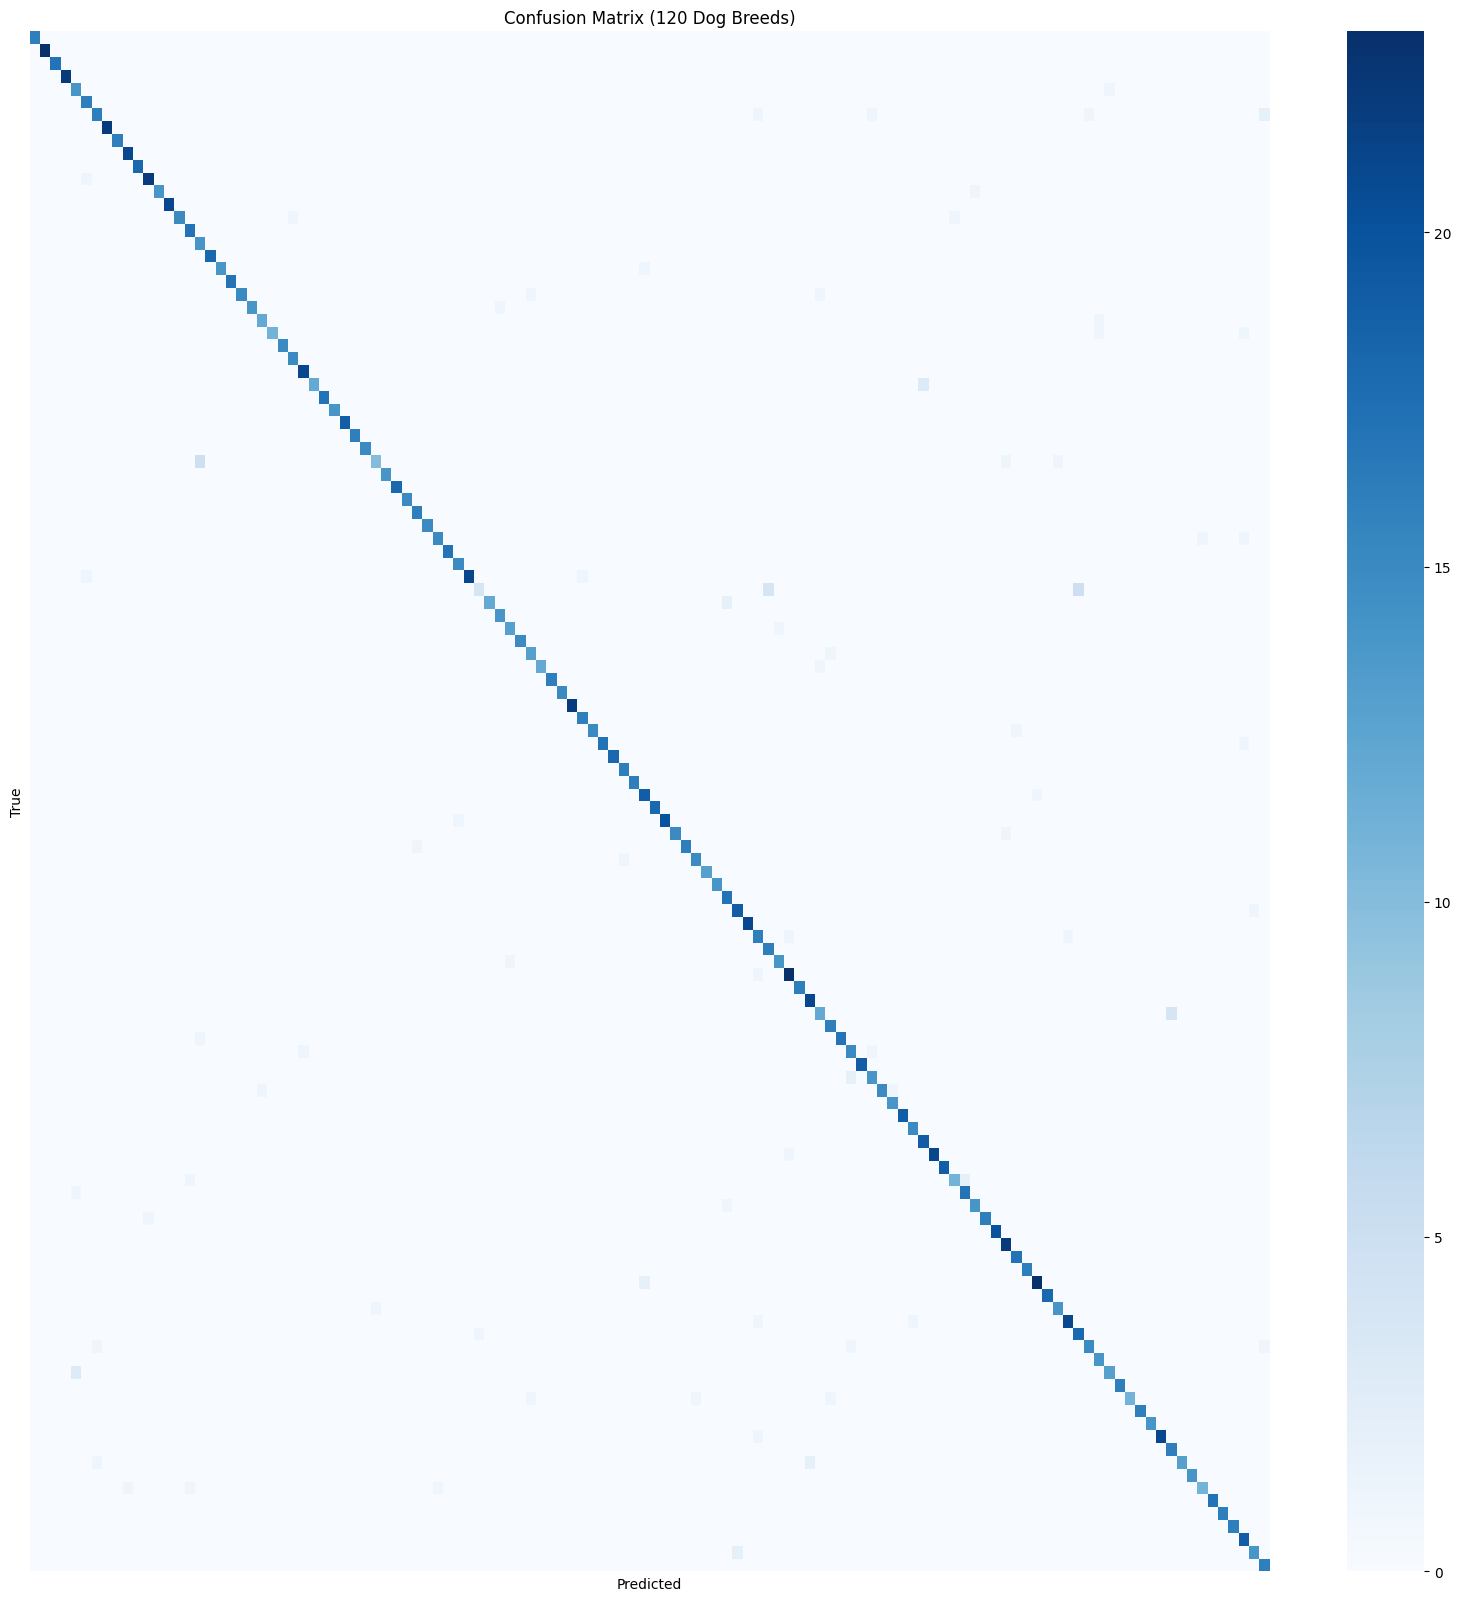


--- MOST CONFUSED PAIRS ---
               True Breed                   Predicted As  Count
               eskimo_dog                 siberian_husky      5
                   collie                  border_collie      5
               eskimo_dog                       malamute      4
         miniature_poodle                     toy_poodle      4
                 cardigan                       pembroke      3
staffordshire_bullterrier american_staffordshire_terrier      3
    flat-coated_retriever             labrador_retriever      2
                  redbone            rhodesian_ridgeback      2
          norwich_terrier                norfolk_terrier      2
              toy_terrier             miniature_pinscher      2


In [27]:
def evaluate_model_performance(dataset, class_names, model_path="best_model_stage2.keras"):
    y_true = []
    y_pred = []
    
    model = keras.models.load_model(model_path, safe_mode=False)

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    print("-" * 30)

    # ---------------------------------------------------------
    # PART 1: Classification Report
    # ---------------------------------------------------------
    print("\n--- CLASSIFICATION REPORT (Top/Bottom Performers) ---")
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    df_breeds = df_report.iloc[:-3, :].sort_values(by='f1-score', ascending=False)
    
    print("\nTop 5 Breeds (Best F1-Score):")
    print(df_breeds.head(5)[['precision', 'recall', 'f1-score']])
    
    print("\nBottom 5 Breeds (Worst F1-Score):")
    print(df_breeds.tail(5)[['precision', 'recall', 'f1-score']])
    
    # ---------------------------------------------------------
    # PART 2: Confusion Matrix Heatmap
    # ---------------------------------------------------------
    print("\n--- CONFUSION MATRIX ---")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=False, yticklabels=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (120 Dog Breeds)')
    plt.show()

    # -----------------------------
    # PART 3: Most Confused Pairs 
    # -----------------------------
    print("\n--- MOST CONFUSED PAIRS ---")
    np.fill_diagonal(cm, 0)
    
    pairs = []
    for i in range(120):
        for j in range(120):
            if cm[i, j] > 0:
                pairs.append({
                    'True Breed': class_names[i],
                    'Predicted As': class_names[j],
                    'Count': cm[i, j]
                })
    
    df_confusion = pd.DataFrame(pairs).sort_values(by='Count', ascending=False)
    print(df_confusion.head(10).to_string(index=False))


evaluate_model_performance(val_ds, class_names, model_path="best_model_stage2.keras")

Predykcja modelu EfficientNetV2L Transfer learning

1/1 [==============================] - 5s 5s/step


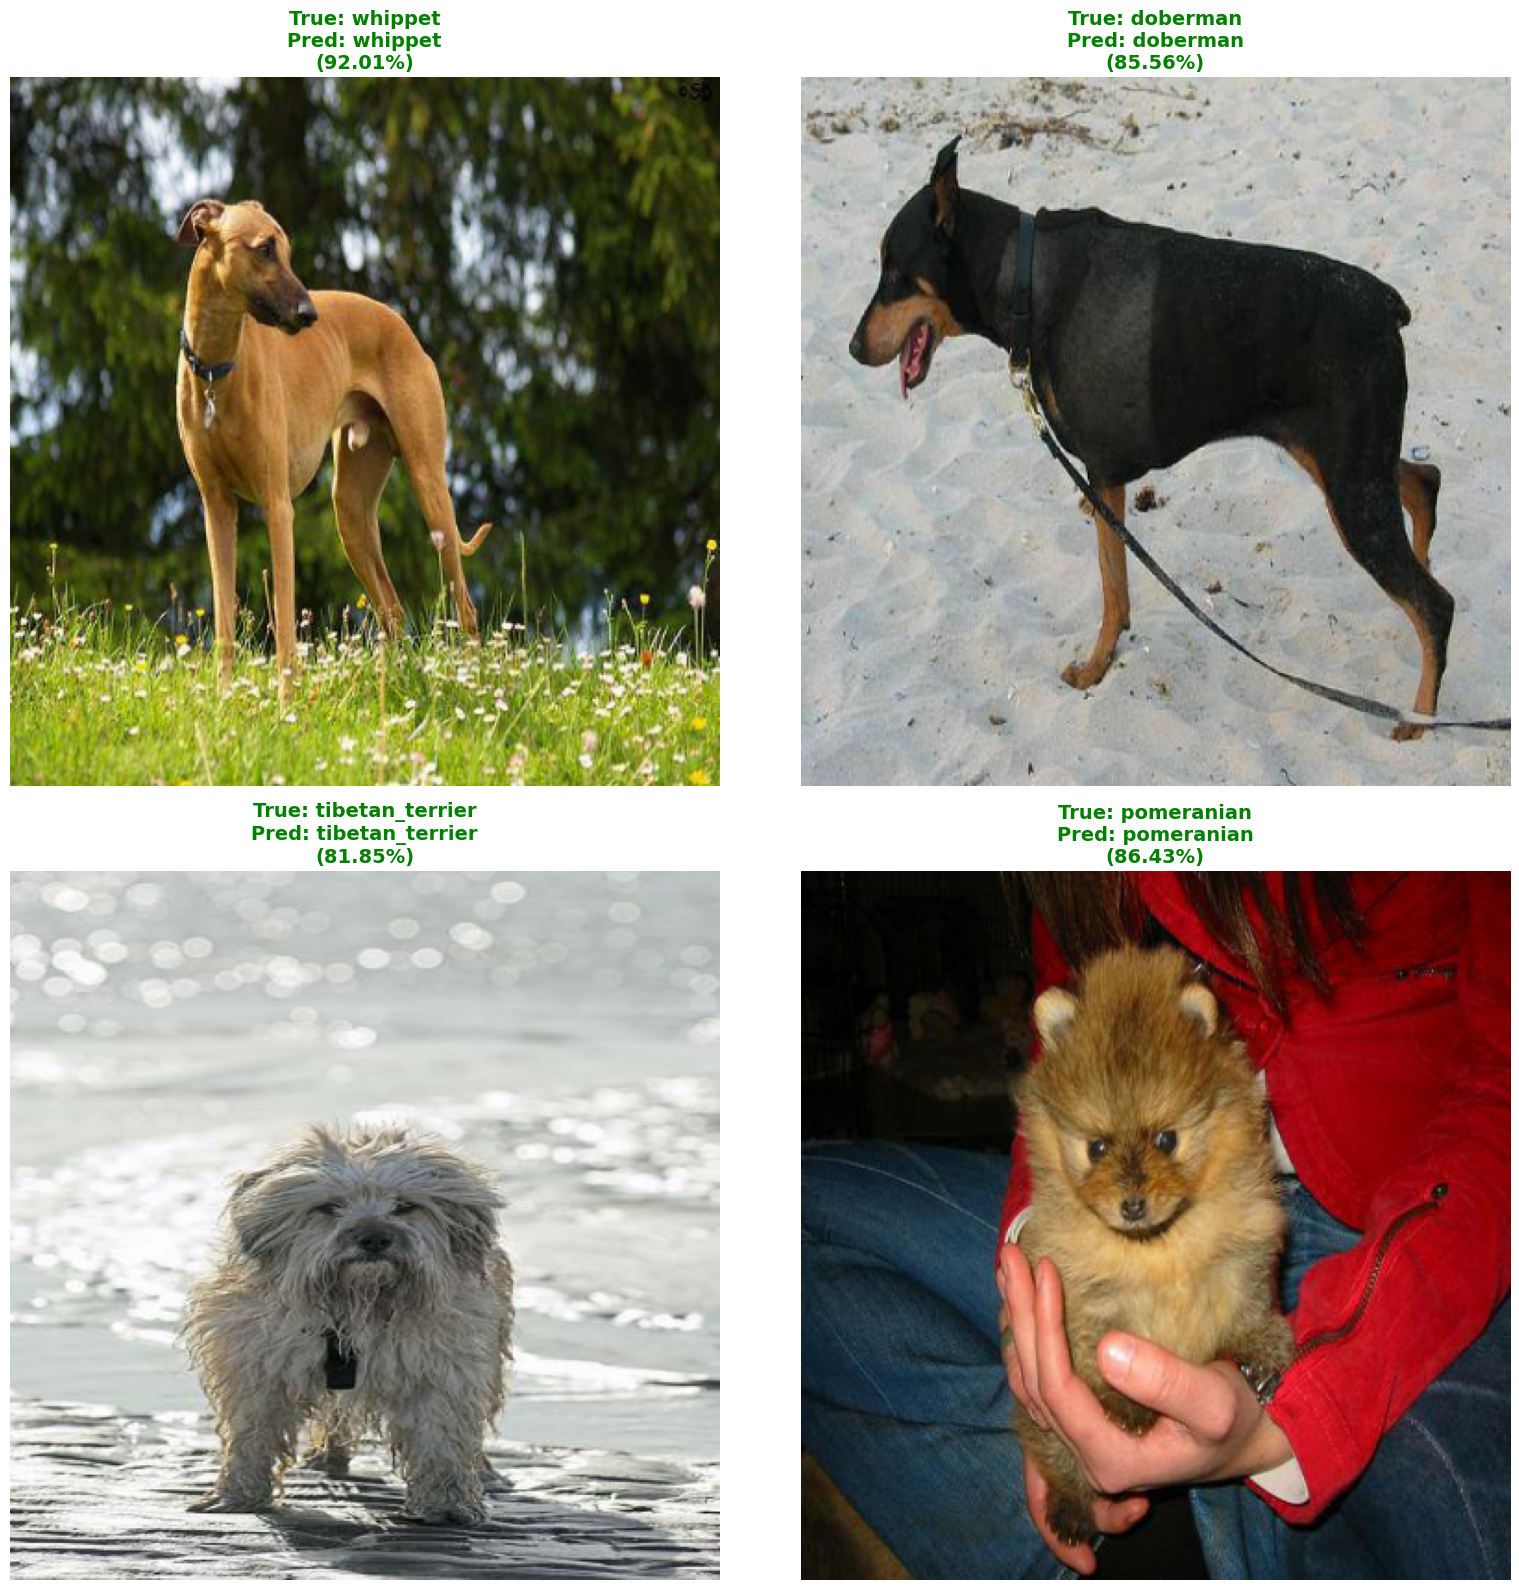

In [25]:
def predict_and_display(dataset, class_names, model_path="best_model_stage2.keras"):

    model = keras.models.load_model(model_path, safe_mode=False)
    
    demo_ds = dataset.shuffle(1000).take(1)
    
    plt.figure(figsize=(16, 16))
    
    for images, labels in demo_ds:
        preds = model.predict(images)
        
        current_batch_size = len(images)
        if current_batch_size < 4:
            indices = range(current_batch_size)
        else:
            indices = np.random.choice(range(current_batch_size), 4, replace=False)
        
        for i, idx in enumerate(indices):
            ax = plt.subplot(2, 2, i + 1)
            
            img = images[idx].numpy().astype("uint8")
            true_label_idx = np.argmax(labels[idx])
            true_label = class_names[true_label_idx]
            
            pred_label_idx = np.argmax(preds[idx])
            pred_label = class_names[pred_label_idx]
            confidence = 100 * np.max(preds[idx])
            
            color = 'green' if true_label_idx == pred_label_idx else 'red'
            
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {pred_label}\n({confidence:.2f}%)", 
                      color=color, fontsize=14, fontweight='bold')
            plt.axis("off")
            
    plt.tight_layout()
    plt.show()


predict_and_display(val_ds, class_names, model_path="best_model_stage2.keras")

Prosty model CNN dla porownania

In [ ]:
def simple_cnn_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    # scale pixel values from [0, 255] to [0, 1]
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs, outputs, name="Simple_CNN")

    return model


model_simple_cnn = simple_cnn_model()
model_simple_cnn.summary()

Model: "Simple_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 384, 384, 3)       0         
                                                                 
 rescaling_1 (Rescaling)     (None, 384, 384, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 384, 384, 32)      864       
                                                                 
 batch_normalization (Batch  (None, 384, 384, 32)      128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 384, 384, 32)      0         
                                                        

Kompilowanie i trening nowego modelu

In [29]:
SIMPLE_CNN_EPOCHS = 50

model_simple_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics = [
        keras.metrics.CategoricalAccuracy(name="top1"),
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5")
    ]
)

callbacks_simple_cnn_model = [
    keras.callbacks.ModelCheckpoint(
        "best_model_simple_cnn.keras", 
        save_best_only=True, 
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss")
]

history_simple_cnn = model_simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=SIMPLE_CNN_EPOCHS,
    callbacks = callbacks_simple_cnn_model
)

Epoch 1/50


W0000 00:00:1770594260.794218   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.798904   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.801285   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.804331   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.807100   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.811451   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.815588   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.818584   67688 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594260.824147   67688 gp

  1/256 [..............................] - ETA: 19:18 - loss: 5.0776 - top1: 0.0000e+00 - top5: 0.0000e+00

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1770594263.082812   67683 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594263.083790   67683 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594263.085391   67683 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594263.086786   67683 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594263.088121   67683 gpu_timer.cc:114] Skipping the delay kernel, measu

  2/256 [..............................] - ETA: 2:26 - loss: 5.1558 - top1: 0.0000e+00 - top5: 0.0312     

...

256/256 [==============================] - 19s 74ms/step - loss: 4.4371 - top1: 0.0471 - top5: 0.1708 - val_loss: 4.8753 - val_top1: 0.0381 - val_top5: 0.1359 - lr: 0.0010
Epoch 9/50
256/256 [==============================] - ETA: 0s - loss: 4.3668 - top1: 0.0558 - top5: 0.1883

W0000 00:00:1770594434.874261   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.881874   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.883206   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.884960   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.886899   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.888994   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.891382   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.893874   67691 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594434.896111   67691 gp

256/256 [==============================] - 19s 73ms/step - loss: 4.3668 - top1: 0.0558 - top5: 0.1883 - val_loss: 4.4228 - val_top1: 0.0587 - val_top5: 0.2000 - lr: 0.0010
Epoch 10/50
256/256 [==============================] - ETA: 0s - loss: 4.2890 - top1: 0.0659 - top5: 0.2155

W0000 00:00:1770594454.076427   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.084771   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.086111   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.088076   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.090040   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.092174   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.094625   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.096961   67686 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1770594454.099464   67686 gp

256/256 [==============================] - 19s 74ms/step - loss: 4.2890 - top1: 0.0659 - top5: 0.2155 - val_loss: 4.7628 - val_top1: 0.0259 - val_top5: 0.0939 - lr: 0.0010
Epoch 11/50
256/256 [==============================] - 19s 73ms/step - loss: 4.2392 - top1: 0.0706 - top5: 0.2250 - val_loss: 4.8923 - val_top1: 0.0328 - val_top5: 0.1286 - lr: 0.0010
Epoch 12/50
256/256 [==============================] - 19s 73ms/step - loss: 4.1612 - top1: 0.0779 - top5: 0.2468 - val_loss: 4.3950 - val_top1: 0.0597 - val_top5: 0.2024 - lr: 0.0010
Epoch 13/50
256/256 [==============================] - 19s 74ms/step - loss: 4.0987 - top1: 0.0887 - top5: 0.2679 - val_loss: 4.3396 - val_top1: 0.0655 - val_top5: 0.2073 - lr: 0.0010
Epoch 14/50
256/256 [==============================] - 19s 73ms/step - loss: 4.0074 - top1: 0.1027 - top5: 0.2940 - val_loss: 4.6282 - val_top1: 0.0386 - val_top5: 0.1521 - lr: 0.0010
Epoch 15/50
256/256 [==============================] - 19s 73ms/step - loss: 3.9649 - top1: 

Ewaluacja modelu CNN

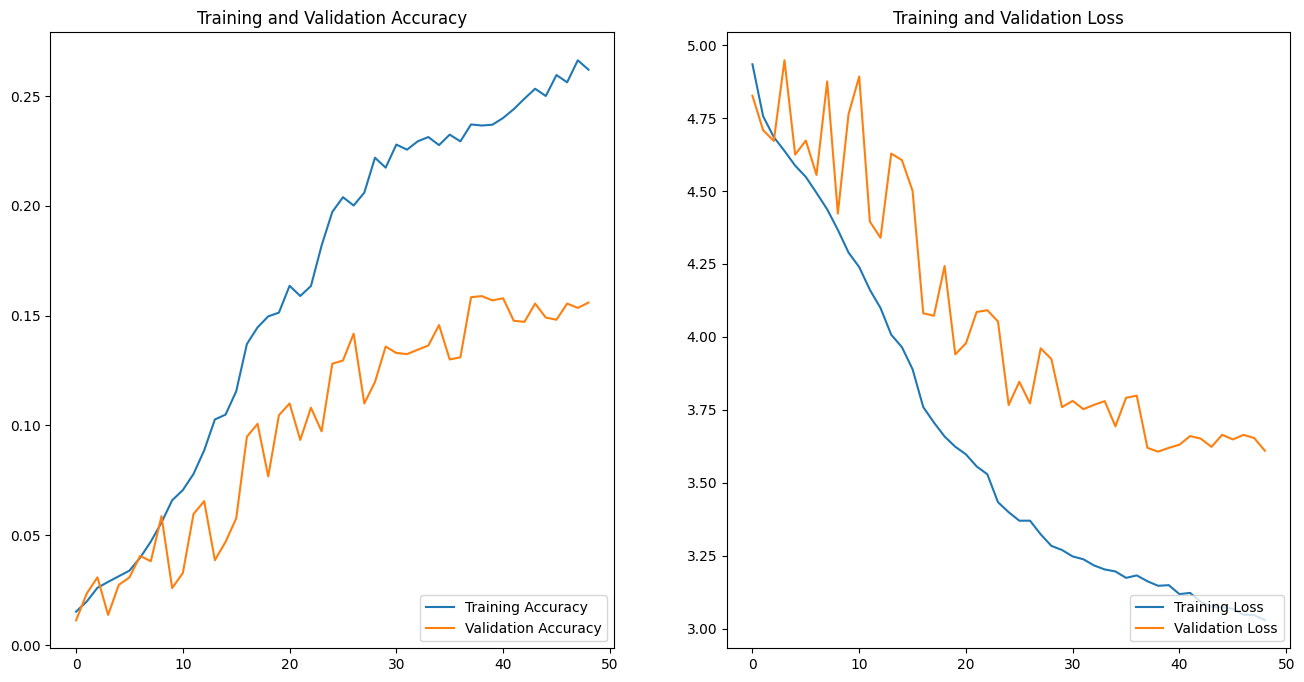

------------------------------

--- CLASSIFICATION REPORT (Top/Bottom Performers) ---

Top 5 Breeds (Best F1-Score):
                         precision    recall  f1-score
black-and-tan_coonhound   0.636364  0.466667  0.538462
english_foxhound          0.583333  0.411765  0.482759
keeshond                  0.461538  0.375000  0.413793
japanese_spaniel          0.538462  0.333333  0.411765
irish_setter              0.380952  0.444444  0.410256

Bottom 5 Breeds (Worst F1-Score):
                    precision  recall  f1-score
bluetick                  0.0     0.0       0.0
standard_poodle           0.0     0.0       0.0
standard_schnauzer        0.0     0.0       0.0
tibetan_mastiff           0.0     0.0       0.0
toy_poodle                0.0     0.0       0.0

--- CONFUSION MATRIX ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


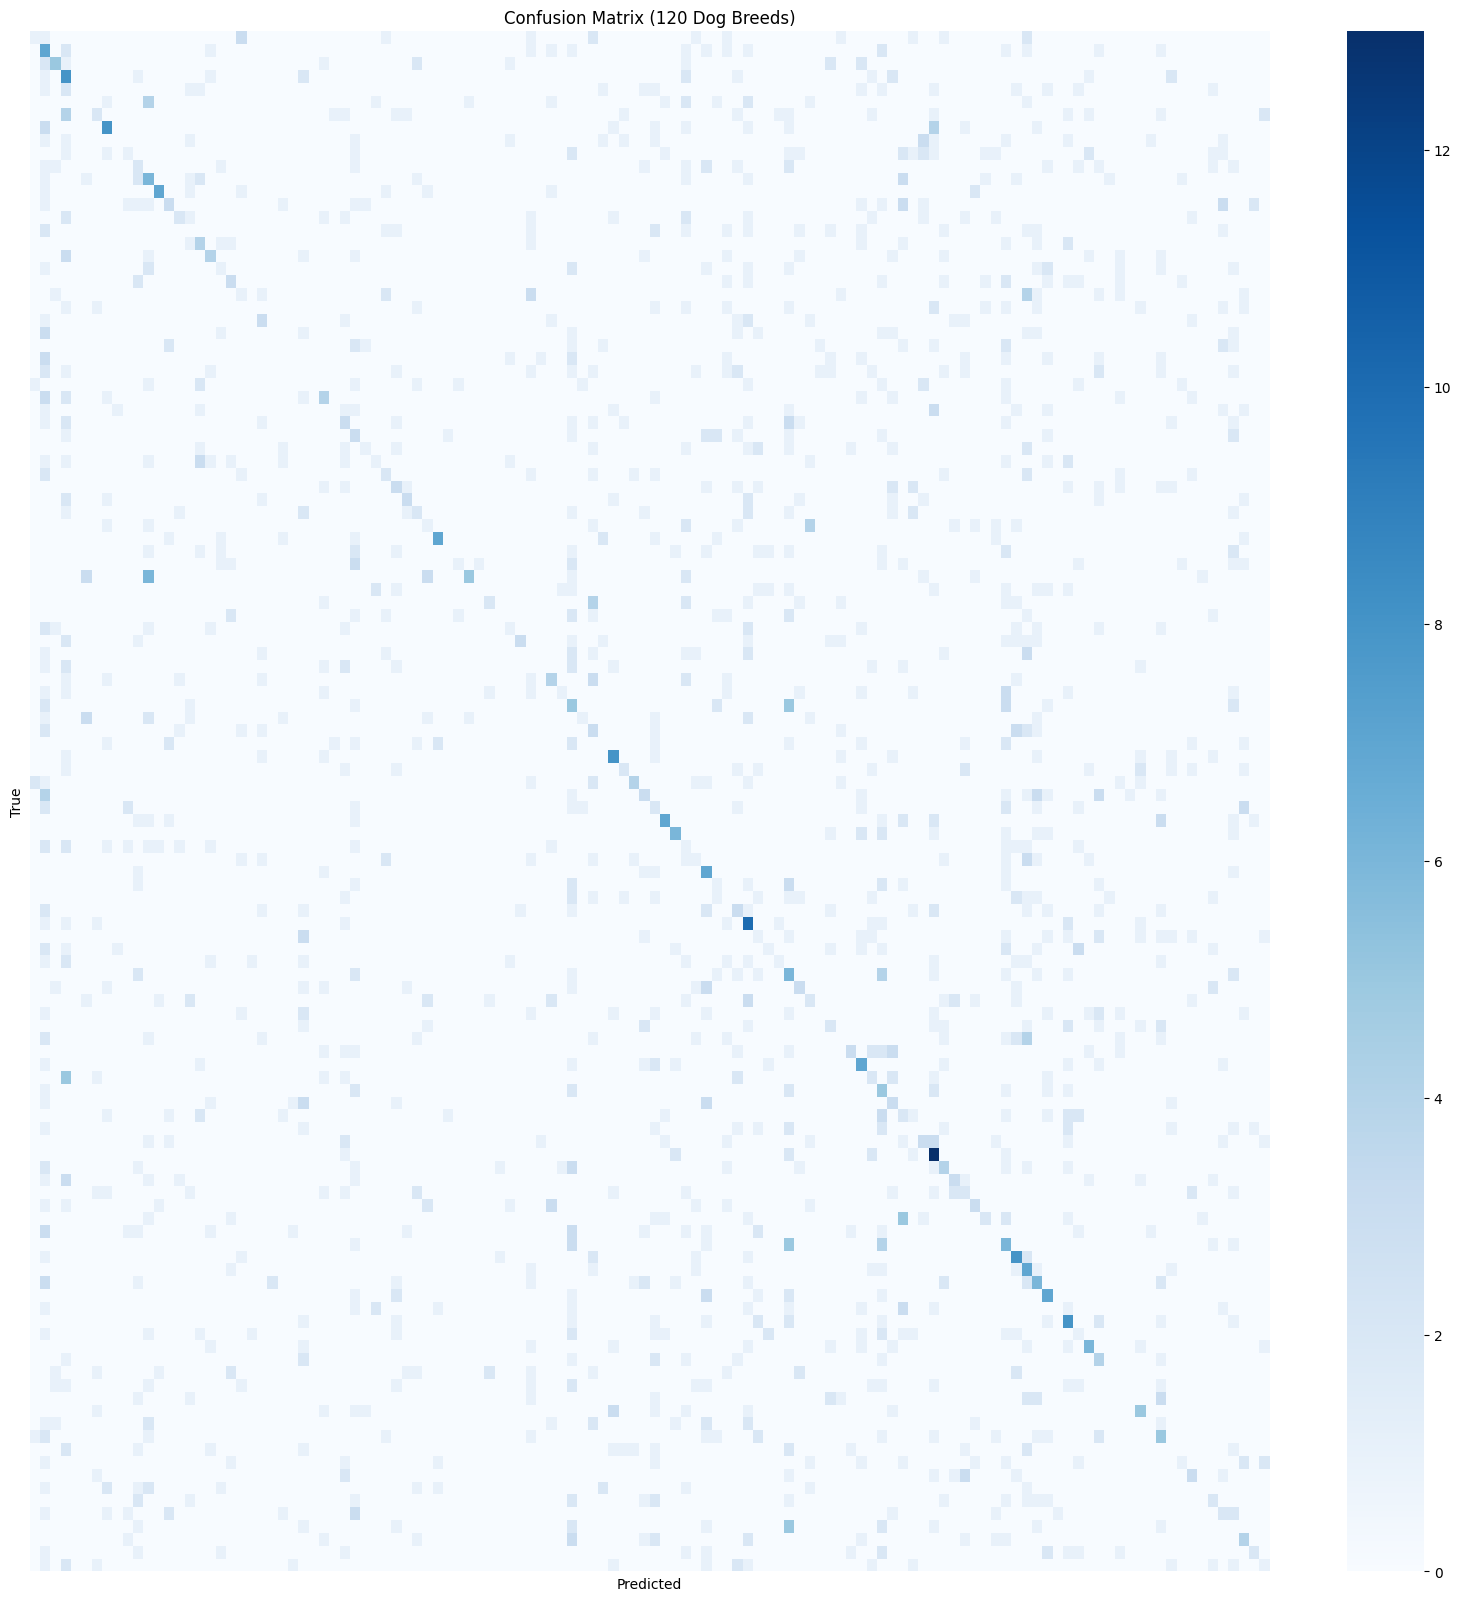


--- MOST CONFUSED PAIRS ---
                 True Breed         Predicted As  Count
                entlebucher bernese_mountain_dog      6
              saint_bernard             papillon      5
                    samoyed          maltese_dog      5
             great_pyrenees          maltese_dog      5
            norwich_terrier             airedale      5
west_highland_white_terrier          maltese_dog      5
                maltese_dog old_english_sheepdog      4
      flat-coated_retriever          groenendael      4
                    basenji           pomeranian      4
               newfoundland       scotch_terrier      4


In [30]:
plot_history(history_simple_cnn)
evaluate_model_performance(val_ds, class_names, model_path="best_model_simple_cnn.keras")

Przykladowa predykcja modelu

1/1 [==============================] - 0s 139ms/step


2026-02-09 00:43:58.447707: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 56638464 bytes after encountering the first element of size 56638464 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


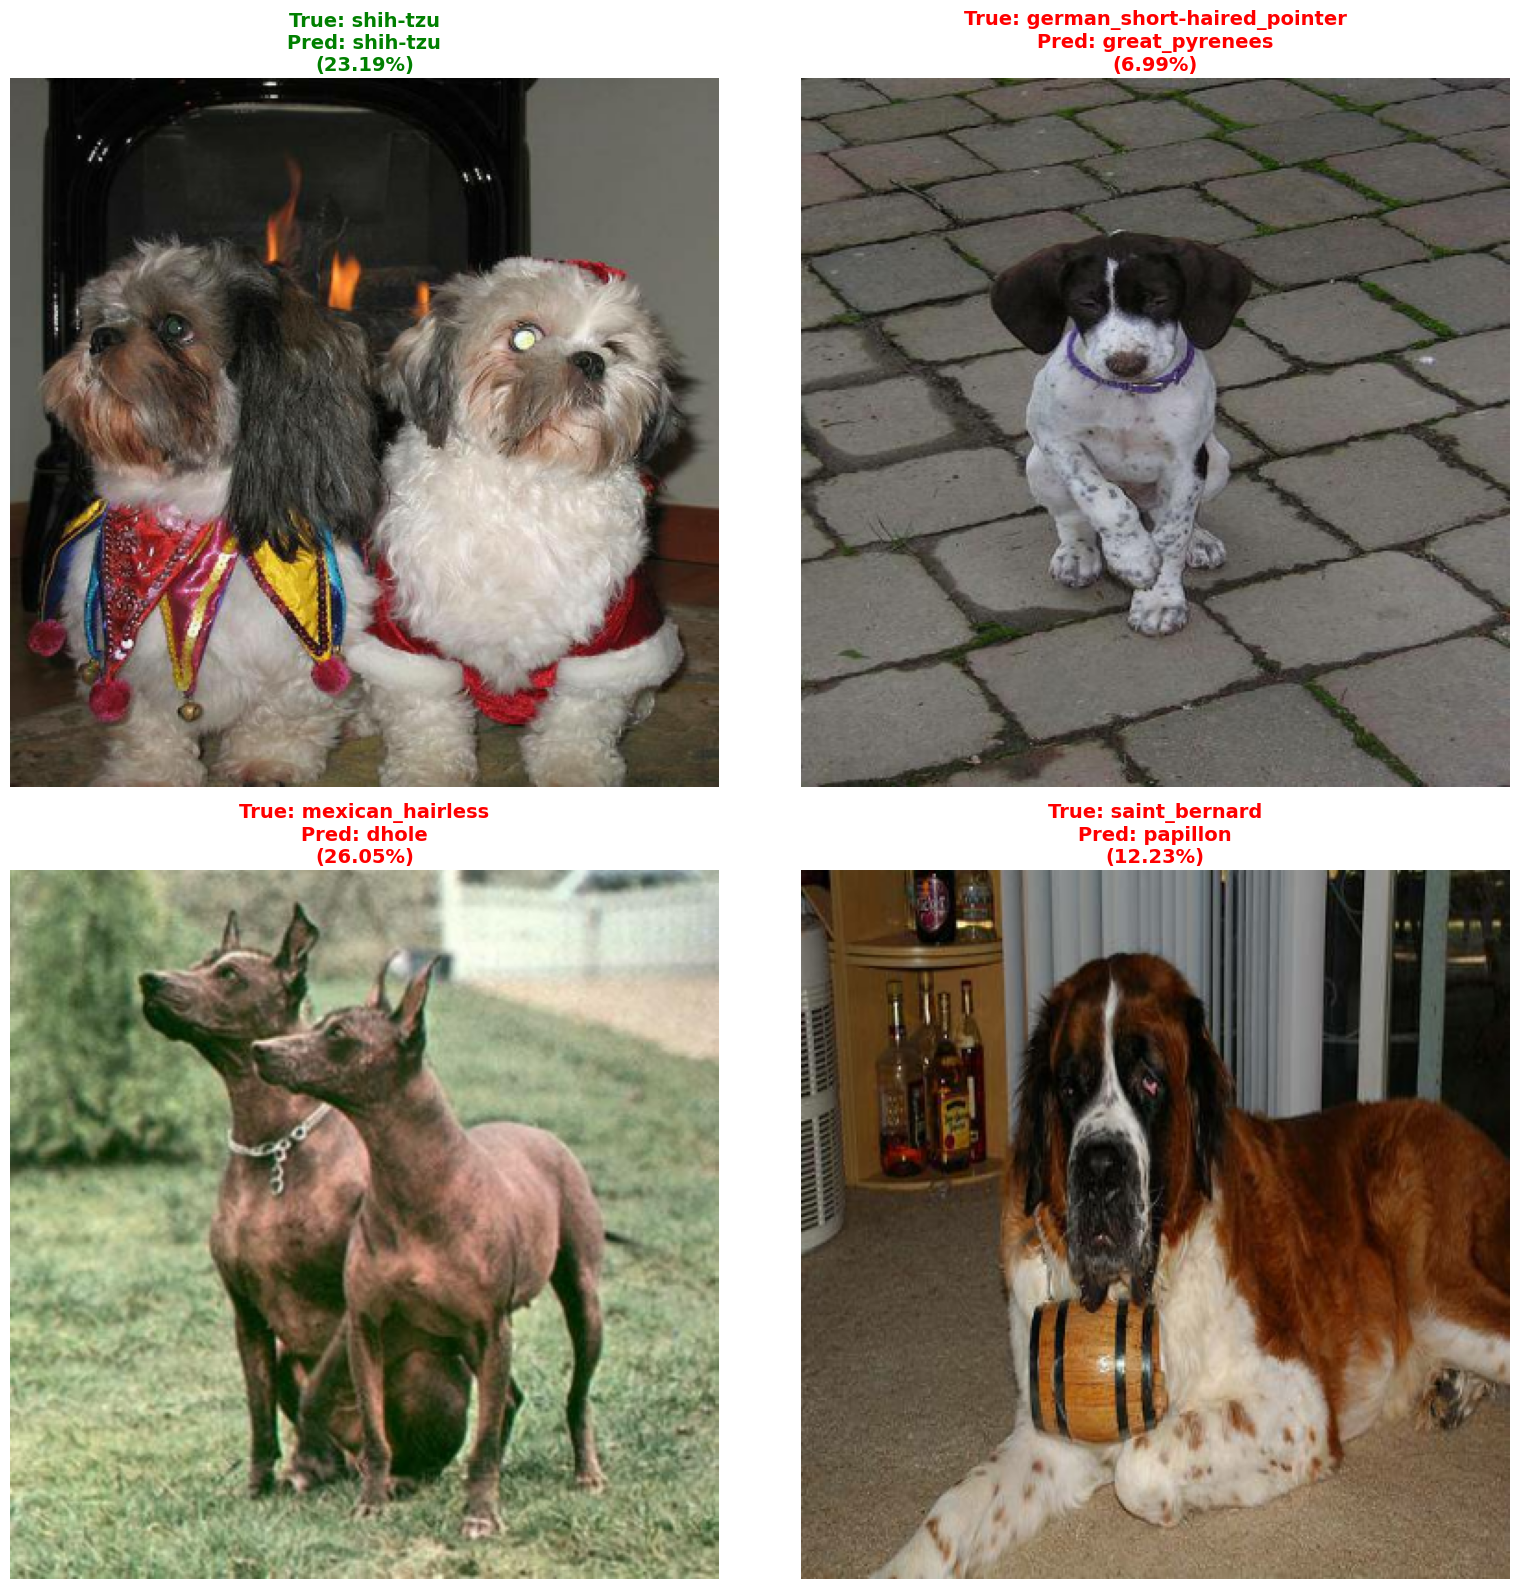

In [34]:
predict_and_display(val_ds, class_names, model_path="best_model_simple_cnn.keras")

Porownanie metryk modeli na jednym wykresie

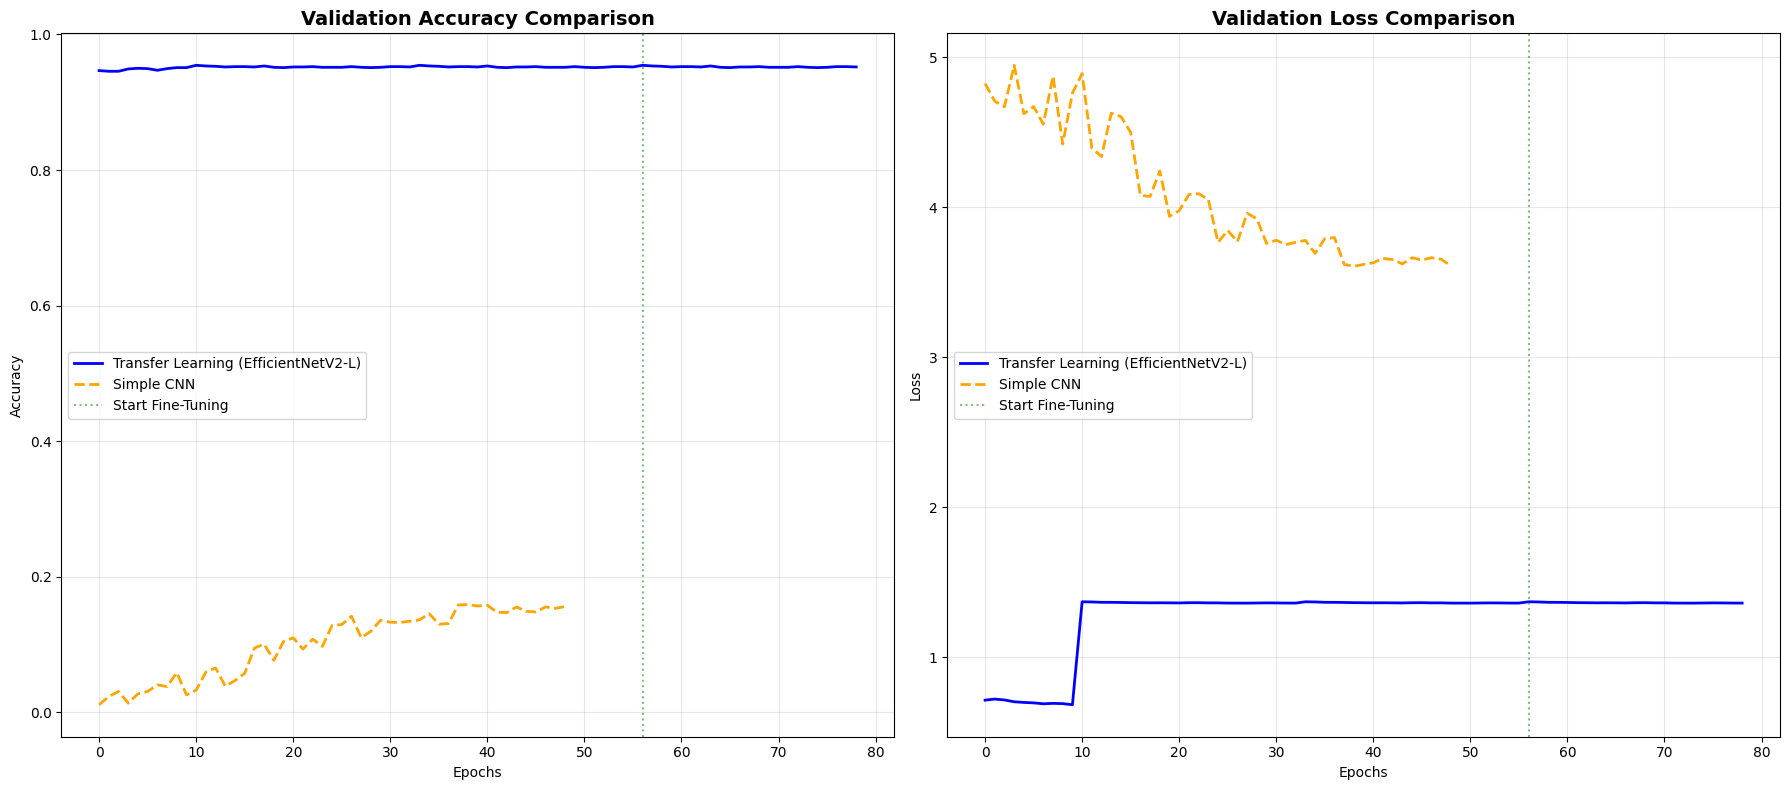

In [36]:
def compare_models(history_stage1, history_stage2, history_simple):
    tl_val_acc = history_stage1.history['val_top1'] + history_stage2.history['val_top1']
    tl_val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']
    
    simple_val_acc = history_simple.history['val_top1']
    simple_val_loss = history_simple.history['val_loss']
    
    plt.figure(figsize=(18, 8))
    
    plt.subplot(1, 2, 1)
    plt.plot(tl_val_acc, label='Transfer Learning (EfficientNetV2-L)', color='blue', linewidth=2)
    plt.plot(simple_val_acc, label='Simple CNN', color='orange', linestyle='--', linewidth=2)
    plt.axvline(x=len(history_stage1.history['val_top1']), color='green', alpha=0.5, linestyle=':', label='Start Fine-Tuning')
    
    plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(tl_val_loss, label='Transfer Learning (EfficientNetV2-L)', color='blue', linewidth=2)
    plt.plot(simple_val_loss, label='Simple CNN', color='orange', linestyle='--', linewidth=2)
    
    plt.axvline(x=len(history_stage1.history['val_loss']), color='green', alpha=0.5, linestyle=':', label='Start Fine-Tuning')
    
    plt.title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


compare_models(history_stage1, history_stage2, history_simple_cnn)

Wizaulizacja decyzyjnosci modeli poprzez LIME (Local Interpretable Model-agnostic Explanations)

--- LIME dla Transfer Learning Model ---
1/1 [==============================] - 0s 42ms/step


2026-02-09 01:03:25.994612: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1769952 bytes after encountering the first element of size 1769952 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
100%|██████████| 1000/1000 [00:33<00:00, 30.01it/s]


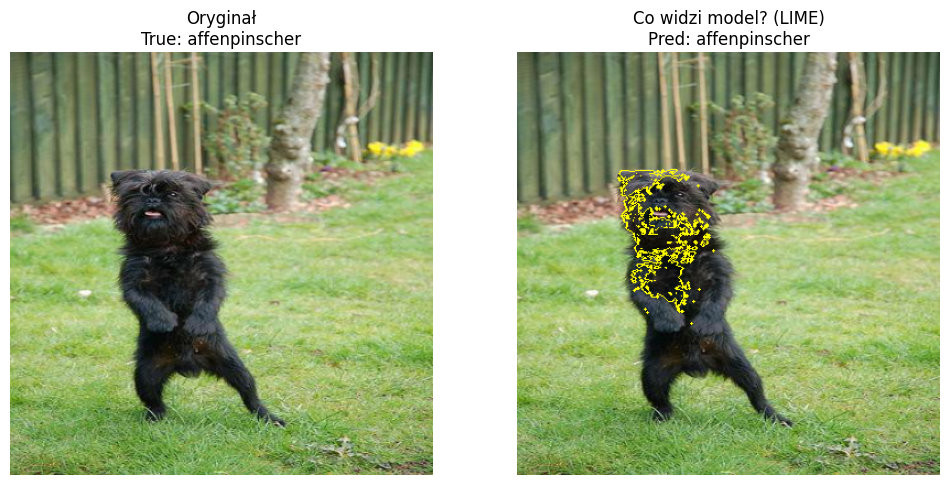

--- LIME dla Simple CNN ---
1/1 [==============================] - 0s 20ms/step


100%|██████████| 1000/1000 [00:15<00:00, 65.05it/s]


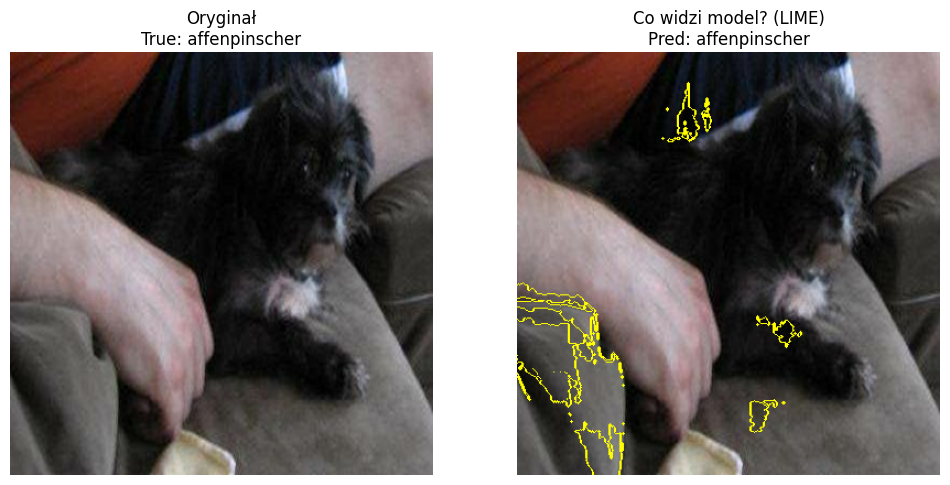

In [43]:
def explain_prediction_lime(model, dataset, class_names, num_samples=1):
    explainer = lime_image.LimeImageExplainer()

    demo_ds = dataset.unbatch().shuffle(200).batch(1).take(num_samples)

    for images, labels in demo_ds:
        img_tensor = images[0]
        img_numpy = img_tensor.numpy().astype("double")
        
        true_label_idx = np.argmax(labels[0])
        true_breed = class_names[true_label_idx]

        preds = model.predict(images)
        pred_label_idx = np.argmax(preds[0])
        pred_breed = class_names[pred_label_idx]

        def predict_fn(images):
            return model.predict(images, verbose=0)

        explanation = explainer.explain_instance(
            img_numpy, 
            predict_fn, 
            top_labels=5, 
            hide_color=0, 
            num_samples=1000
        )

        temp, mask = explanation.get_image_and_mask(
            pred_label_idx, 
            positive_only=True, 
            num_features=5, 
            hide_rest=False
        )

        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(img_numpy.astype("uint8"))
        plt.title(f"Oryginał\nTrue: {true_breed}")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(mark_boundaries(temp.astype("uint8"), mask))
        plt.title(f"Co widzi model? (LIME)\nPred: {pred_breed}")
        plt.axis('off')
        
        plt.show()


print("--- LIME dla Transfer Learning Model ---")
explain_prediction_lime(model, val_ds, class_names)

print("--- LIME dla Simple CNN ---")
explain_prediction_lime(model_simple_cnn, val_ds, class_names)

### Wnioski

 Model oparty na EfficientNetV2-L osiągnął okolo 95% dokładności już w pierwszej fazie treningu, zauwazalnie wygrywajac z prostą sieć CNN trenowaną od zera. 
 
 Przy małym zbiorze danych tj. 10 tys. zdjęć, wykorzystanie gotowych wag z ImageNet okazało się kluczowe do poprawnej klasyfikacji ras psów.

Fine-Tuning okazał się w tym przypadku praktycznie zbedny, poniewaz model osiągnął swoją maksymalną skuteczność już podczas pierwszej fazy treningu. 

Dalsze douczanie w Stage 2 przyniosło jedynie marginalny wzrost dokładności.

Ze wzgledu na silna regularyzacje model uniknął przeuczenia w 2 fazie, a wzrost funkcji straty jest technicznym skutkiem zmiany parametrów wygładzania.